In [ ]:
# # ============================================================
# # STEP 0: INSTALL & MOUNT GOOGLE DRIVE
# # ============================================================

# !unzip -q DATASET.zip -d /content

In [ ]:
# from google.colab import drive
# drive.mount('/content/drive')

In [ ]:
import os
os.environ["PYTORCH_CUDA_ALLOC_CONF"] = "expandable_segments:True"

In [ ]:
!pip install albumentations

In [ ]:
# ============================================================
# STEP 1: IMPORTS & CONFIG
# ============================================================
import os, cv2, random
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import albumentations as A
from albumentations.pytorch import ToTensorV2
from tqdm import tqdm
import matplotlib.pyplot as plt

device = "cuda" if torch.cuda.is_available() else "cpu"

# ================= PATHS =================
DATASET_ROOT = "/content/DATASET"
MODEL_DIR = "/content/SWIN UNET MODEL"
os.makedirs(MODEL_DIR, exist_ok=True)
MODEL_PATH = f"{MODEL_DIR}/best_swin_unet.pth"

# ================= TRAINING CONFIG =================
NUM_CLASSES = 8   # background + 7 organs
BATCH_SIZE = 1 # Reduced from 4 to 2 to conserve GPU memory
LR = 3e-5
EPOCHS = 50
PATIENCE = 10
SEED = 42

torch.manual_seed(SEED)
random.seed(SEED)
np.random.seed(SEED)

In [ ]:
# ============================================================
# STEP 2: DATASET CLASS
# ============================================================
class SegDataset(Dataset):
    def __init__(self, img_dir, mask_dir, augment=False):
        self.img_dir = img_dir
        self.mask_dir = mask_dir
        self.files = sorted(os.listdir(img_dir))

        if augment:
            self.tf = A.Compose([
                A.HorizontalFlip(p=0.5),
                A.VerticalFlip(p=0.5),
                A.RandomRotate90(p=0.5),
                A.Normalize(),
                ToTensorV2()
            ])
        else:
            self.tf = A.Compose([
                A.Normalize(),
                ToTensorV2()
            ])

    def __len__(self):
        return len(self.files)

    def __getitem__(self, idx):
        name = self.files[idx]

        img = cv2.cvtColor(
            cv2.imread(os.path.join(self.img_dir, name)),
            cv2.COLOR_BGR2RGB
        )

        mask = cv2.imread(os.path.join(self.mask_dir, name), 0)

        img = cv2.resize(img, (224, 224), interpolation=cv2.INTER_LINEAR)
        mask = cv2.resize(mask, (224, 224), interpolation=cv2.INTER_NEAREST)

        # print(img.shape)   # should be [3, 224, 224]
        # print(mask.shape)  # should be [224, 224]

        aug = self.tf(image=img, mask=mask)
        img, mask = aug["image"], aug["mask"]

        # ---- ORGAN PRESENCE VECTOR ----
        presence = torch.zeros(NUM_CLASSES)
        for c in range(1, NUM_CLASSES):
            if torch.any(mask == c):
                presence[c] = 1.0

        return img, mask.long(), presence

In [ ]:
!pip install timm

In [ ]:
# ============================================================
# STEP 3: SWIN UNET MODEL
# ============================================================

import timm
import torch
import torch.nn as nn
import torch.nn.functional as F

class ConvBlock(nn.Module):
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, 3, padding=1),
            nn.GroupNorm(8, out_ch),   # 🔑 stable for batch=1
            nn.ReLU(inplace=True),
            nn.Conv2d(out_ch, out_ch, 3, padding=1),
            nn.GroupNorm(8, out_ch),
            nn.ReLU(inplace=True)
        )

    def forward(self, x):
        return self.block(x)


class SwinUNet(nn.Module):
    def __init__(self, num_classes):
        super().__init__()

        # -------- Swin Transformer Encoder --------
        self.encoder = timm.create_model(
            "swin_base_patch4_window7_224",
            pretrained=True,
            features_only=True
        )

        enc_channels = self.encoder.feature_info.channels()
        # [128, 256, 512, 1024]

        # -------- Decoder --------
        self.up4 = ConvBlock(enc_channels[3], 512)
        self.up3 = ConvBlock(512 + enc_channels[2], 256)
        self.up2 = ConvBlock(256 + enc_channels[1], 128)
        self.up1 = ConvBlock(128 + enc_channels[0], 64)

        self.seg_head = nn.Conv2d(64, num_classes, kernel_size=1)

    def forward(self, x):
      feats = self.encoder(x)

      # 🔑 timm Swin outputs NHWC → convert to NCHW
      feats = [f.permute(0, 3, 1, 2).contiguous() for f in feats]

      f1, f2, f3, f4 = feats
      # f1: [B,128,56,56]
      # f2: [B,256,28,28]
      # f3: [B,512,14,14]
      # f4: [B,1024,7,7]

      d4 = F.interpolate(f4, size=f3.shape[2:], mode="bilinear", align_corners=False)
      d4 = self.up4(d4)

      d3 = F.interpolate(d4, size=f3.shape[2:], mode="bilinear", align_corners=False)
      d3 = self.up3(torch.cat([d3, f3], dim=1))

      d2 = F.interpolate(d3, size=f2.shape[2:], mode="bilinear", align_corners=False)
      d2 = self.up2(torch.cat([d2, f2], dim=1))

      d1 = F.interpolate(d2, size=f1.shape[2:], mode="bilinear", align_corners=False)
      d1 = self.up1(torch.cat([d1, f1], dim=1))

      out = self.seg_head(d1)
      out = F.interpolate(out, size=x.shape[2:], mode="bilinear", align_corners=False)

      return out

In [ ]:
# ============================================================
# STEP 4: LOSSES (UNCHANGED)
# ============================================================

class_weights = torch.tensor(
    [1.0, 1.5, 2.0, 1.8, 4.0, 2.5, 2.0, 1.8],
    device=device
)

seg_bce_loss = nn.BCEWithLogitsLoss(weight=class_weights.view(1, -1, 1, 1))

In [ ]:
# ============================================================
# STEP 5: LOAD DATA
# ============================================================
train_ds = SegDataset(
    f"{DATASET_ROOT}/TRAIN/IMAGE",
    f"{DATASET_ROOT}/TRAIN/MASK",
    augment=True
)

val_ds = SegDataset(
    f"{DATASET_ROOT}/VALIDATION/IMAGE",
    f"{DATASET_ROOT}/VALIDATION/MASK"
)

train_loader = DataLoader(train_ds, BATCH_SIZE, True, num_workers=2)
val_loader   = DataLoader(val_ds, BATCH_SIZE, False, num_workers=2)


In [ ]:
import torch
print(torch.cuda.is_available())

True


In [ ]:
# ============================================================
# STEP 6: TRAINING LOOP (SWIN U-NET)
# ============================================================

from torch.amp import autocast, GradScaler
from tqdm import tqdm

model = SwinUNet(num_classes=NUM_CLASSES,).to(device)

# 🔑 freeze encoder for first few epochs (optional but recommended)
if hasattr(model, "encoder"):
    for p in model.encoder.parameters():
        p.requires_grad = False

optimizer = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=1e-4)
scaler = GradScaler(enabled=torch.cuda.is_available())

best_val_loss = float("inf")
wait = 0

history = {"train_loss": [], "val_loss": []}
dice_history = {"small_intestine": [], "stomach": []}

def dice_per_class(pred, target, eps=1e-5):
    pred = (torch.sigmoid(pred) > 0.5)
    inter = (pred & target.bool()).sum((2,3))
    union = pred.sum((2,3)) + target.sum((2,3))
    return (2 * inter + eps) / (union + eps)

def safe_dice_loss(pred, target, eps=1e-6):
    pred = torch.sigmoid(pred)
    inter = (pred * target).sum((2,3))
    union = pred.sum((2,3)) + target.sum((2,3))
    dice = (2 * inter + eps) / (union + eps)
    return 1 - dice.mean()

for epoch in range(EPOCHS):

    print(f"\n================ Epoch {epoch+1}/{EPOCHS} ================")

    # -------- UNFREEZE after 10 epochs --------
    if epoch == 10 and hasattr(model, "encoder"):
      print("🔓 Unfreezing Swin encoder")
      for p in model.encoder.parameters():
          p.requires_grad = True

    # ================= TRAIN =================
    model.train()
    train_loss = 0.0

    for x, seg_gt, _ in tqdm(train_loader, desc="Training", leave=False):
        x = x.to(device)
        seg_gt = seg_gt.to(device)

        optimizer.zero_grad(set_to_none=True)

        with autocast(device_type="cuda", enabled=torch.cuda.is_available()):
            seg_out = model(x)
            if seg_out.shape[-2:] != seg_gt.shape[-2:]:
                seg_out = torch.nn.functional.interpolate(
                    seg_out,
                    size=seg_gt.shape[-2:],
                    mode="bilinear",
                    align_corners=False
                )

            seg_gt_oh = torch.nn.functional.one_hot(
                seg_gt, NUM_CLASSES
            ).permute(0,3,1,2).float()

            loss = (
                2.0 * safe_dice_loss(seg_out, seg_gt_oh) +
                1.0 * seg_bce_loss(seg_out, seg_gt_oh)
            )

        scaler.scale(loss).backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        scaler.step(optimizer)
        scaler.update()

        train_loss += loss.item()

    train_loss /= len(train_loader)

    # ================= VALIDATION =================
    model.eval()
    val_loss = 0.0
    dice_si, dice_st = [], []

    with torch.no_grad():
        for x, seg_gt, _ in tqdm(val_loader, desc="Validation", leave=False):
            x = x.to(device)
            seg_gt = seg_gt.to(device)

            with autocast(device_type="cuda", enabled=torch.cuda.is_available()):
                seg_out = model(x)

                if seg_out.shape[-2:] != seg_gt.shape[-2:]:
                    seg_out = torch.nn.functional.interpolate(
                        seg_out,
                        size=seg_gt.shape[-2:],
                        mode="bilinear",
                        align_corners=False
                    )

                seg_gt_oh = torch.nn.functional.one_hot(
                    seg_gt, NUM_CLASSES
                ).permute(0,3,1,2).float()

                loss = (
                    2.0 * safe_dice_loss(seg_out, seg_gt_oh) +
                    1.0 * seg_bce_loss(seg_out, seg_gt_oh)
                )

                val_loss += loss.item()

                dice_vals = dice_per_class(seg_out, seg_gt_oh)

                if seg_gt_oh[:,5].sum() > 0:
                    dice_si.append(dice_vals[:, 5].mean().item())
                if seg_gt_oh[:,7].sum() > 0:
                    dice_st.append(dice_vals[:, 7].mean().item())

    val_loss /= len(val_loader)

    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)
    dice_history["small_intestine"].append(np.mean(dice_si) if dice_si else 0.0)
    dice_history["stomach"].append(np.mean(dice_st) if dice_st else 0.0)

    print(
        f"Epoch {epoch+1} | "
        f"Train Loss: {train_loss:.4f} | "
        f"Val Loss: {val_loss:.4f} | "
        f"SI Dice: {dice_history['small_intestine'][-1]:.3f} | "
        f"ST Dice: {dice_history['stomach'][-1]:.3f}"
    )

    # ================= EARLY STOPPING =================
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save(model.state_dict(), MODEL_PATH)
        wait = 0
        print("✅ Model saved")
    else:
        wait += 1
        print(f"⚠️ No improvement ({wait}/{PATIENCE})")
        if wait >= PATIENCE:
            print("⛔ Early stopping triggered")
            break

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


model.safetensors:   0%|          | 0.00/353M [00:00<?, ?B/s]


================ Epoch 1/50 ================


Epoch 1 | Train Loss: 2.3089 | Val Loss: 2.1046 | SI Dice: 0.000 | ST Dice: 0.000
✅ Model saved

================ Epoch 2/50 ================


Epoch 2 | Train Loss: 1.9963 | Val Loss: 1.8836 | SI Dice: 0.000 | ST Dice: 0.553
✅ Model saved

================ Epoch 3/50 ================


...

Epoch 46 | Train Loss: 1.1611 | Val Loss: 1.2626 | SI Dice: 0.872 | ST Dice: 0.885
⚠️ No improvement (3/10)

================ Epoch 47/50 ================


Epoch 47 | Train Loss: 1.1577 | Val Loss: 1.2686 | SI Dice: 0.871 | ST Dice: 0.880
⚠️ No improvement (4/10)

================ Epoch 48/50 ================


Epoch 48 | Train Loss: 1.1599 | Val Loss: 1.2622 | SI Dice: 0.872 | ST Dice: 0.888
⚠️ No improvement (5/10)

================ Epoch 49/50 ================


Epoch 49 | Train Loss: 1.1556 | Val Loss: 1.2627 | SI Dice: 0.875 | ST Dice: 0.882
⚠️ No improvement (6/10)

================ Epoch 50/50 ================


Epoch 50 | Train Loss: 1.1572 | Val Loss: 1.2636 | SI Dice: 0.875 | ST Dice: 0.885
⚠️ No improvement (7/10)


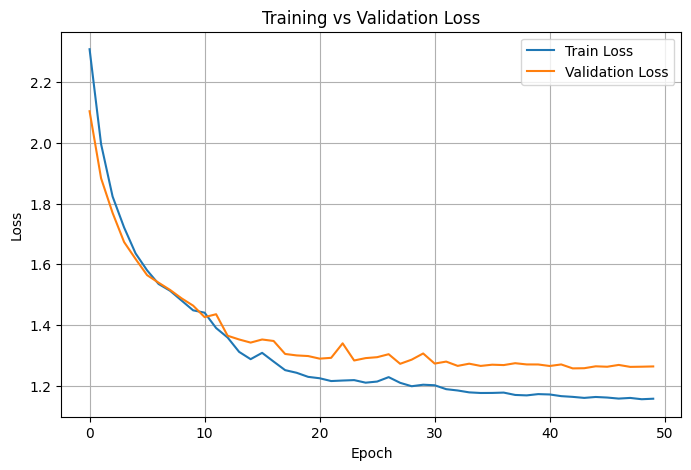

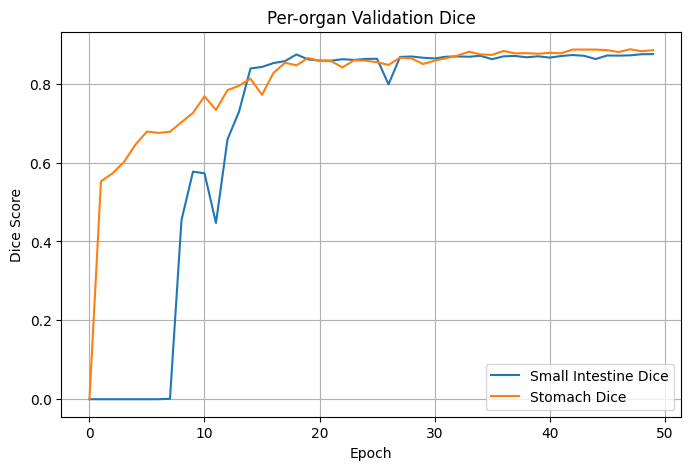

In [ ]:
# ============================================================
# STEP 7: CURVES (FINAL)
# ============================================================

# ---- Loss Curves ----
plt.figure(figsize=(8,5))
plt.plot(history["train_loss"], label="Train Loss")
plt.plot(history["val_loss"], label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.legend()
plt.grid(True)
plt.show()

# ---- Per-organ Dice Curves ----
plt.figure(figsize=(8,5))
plt.plot(dice_history["small_intestine"], label="Small Intestine Dice")
plt.plot(dice_history["stomach"], label="Stomach Dice")
plt.xlabel("Epoch")
plt.ylabel("Dice Score")
plt.title("Per-organ Validation Dice")
plt.legend()
plt.grid(True)
plt.show()


In [ ]:
# ============================================================
# STEP 8: TESTING (DEEPLABV3 – FIXED)
# ============================================================

model = SwinUNet(NUM_CLASSES).to(device)
model.load_state_dict(torch.load(MODEL_PATH, map_location=device))
model.eval()

print("✅ DeepLabV3 + GroupNorm model loaded correctly")

✅ DeepLabV3 + GroupNorm model loaded correctly


In [ ]:
# ---- Class-wise thresholds (important for rare organs) ----
thresholds = {
    1: 0.35,  # abdominal_wall
    2: 0.35,  # colon
    3: 0.35,  # liver
    4: 0.25,  # pancreas
    5: 0.30,  # small_intestine
    6: 0.35,  # spleen
    7: 0.40,  # stomach
}

In [ ]:
# ---- Dice storage ----
dice_scores = {i: [] for i in range(NUM_CLASSES)}

def dice_per_class(pred, target, eps=1e-5):
    inter = (pred & target).sum((2,3))
    union = pred.sum((2,3)) + target.sum((2,3))
    return (2 * inter + eps) / (union + eps)

In [ ]:
# ============================================================
# STEP 7.5: TEST DATASET & LOADER (REQUIRED)
# ============================================================

test_ds = SegDataset(
    img_dir=f"{DATASET_ROOT}/TEST/IMAGE",
    mask_dir=f"{DATASET_ROOT}/TEST/MASK",
    augment=False
)

test_loader = DataLoader(
    test_ds,
    batch_size=1,          # IMPORTANT for segmentation
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

print("✅ test_loader created successfully")

✅ test_loader created successfully


In [ ]:
# ---- Testing loop ----

# ---- Metric accumulators (pixel-wise) ----
tp = torch.zeros(NUM_CLASSES)
fp = torch.zeros(NUM_CLASSES)
fn = torch.zeros(NUM_CLASSES)
tn = torch.zeros(NUM_CLASSES)

with torch.no_grad():
    for x, seg_gt, _ in tqdm(test_loader, desc="Testing"):
        x = x.to(device)
        seg_gt = seg_gt.to(device)   # (1,H,W)

        seg_out = model(x)   # (1,C,H,W)
        prob = torch.sigmoid(seg_out)

        # ---- Threshold per class ----
        pred = torch.zeros_like(prob, dtype=torch.int)
        for c in range(NUM_CLASSES):
            th = thresholds.get(c, 0.5)
            pred[:, c] = (prob[:, c] > th).int()

        # ---- GT one-hot ----
        gt_oh = torch.nn.functional.one_hot(
            seg_gt, NUM_CLASSES
        ).permute(0,3,1,2).int()

        pred_bin = pred.bool()
        gt_bin   = gt_oh.bool()

        for c in range(NUM_CLASSES):
            tp[c] += torch.logical_and(pred_bin[:, c], gt_bin[:, c]).sum().cpu()
            fp[c] += torch.logical_and(pred_bin[:, c], ~gt_bin[:, c]).sum().cpu()
            fn[c] += torch.logical_and(~pred_bin[:, c], gt_bin[:, c]).sum().cpu()
            tn[c] += torch.logical_and(~pred_bin[:, c], ~gt_bin[:, c]).sum().cpu()

        dice = dice_per_class(pred, gt_oh)

        # ---- Presence-aware dice ----
        for c in range(NUM_CLASSES):
            if gt_oh[:, c].sum() > 0:
                dice_scores[c].append(dice[:, c].item())

Testing: 100%|██████████| 72/72 [00:03<00:00, 22.27it/s]


In [ ]:
# ---- Print results ----
print("\n===== TEST RESULTS (Presence-aware Dice) =====")

CLASS_NAMES = [
    "background",
    "abdominal_wall",
    "colon",
    "liver",
    "pancreas",
    "small_intestine",
    "spleen",
    "stomach"
]

for c, name in enumerate(CLASS_NAMES):
    if len(dice_scores[c]) > 0:
        print(f"{name:20s} : {np.mean(dice_scores[c]):.4f}")
    else:
        print(f"{name:20s} : N/A (not present)")


===== TEST RESULTS (Presence-aware Dice) =====
background           : 0.9820
abdominal_wall       : 0.9149
colon                : 0.7857
liver                : 0.8155
pancreas             : 0.6349
small_intestine      : 0.9608
spleen               : 0.9248
stomach              : 0.9002


In [ ]:
eps = 1e-7

precision = tp / (tp + fp + eps)
recall    = tp / (tp + fn + eps)
dice_all  = (2 * tp) / (2 * tp + fp + fn + eps)
iou       = tp / (tp + fp + fn + eps)
accuracy  = (tp + tn) / (tp + tn + fp + fn + eps)
f1        = dice_all  # Dice == F1 for segmentation

print("\n===== FULL SEGMENTATION EVALUATION =====\n")
print(f"{'Class':20s} | Acc | Prec | Recall | Dice | IoU")
print("-" * 70)

for c, name in enumerate(CLASS_NAMES):
    print(
        f"{name:20s} | "
        f"{accuracy[c]:.3f} | "
        f"{precision[c]:.3f} | "
        f"{recall[c]:.3f} | "
        f"{dice_all[c]:.3f} | "
        f"{iou[c]:.3f}"
    )

print("\n===== OVERALL MODEL PERFORMANCE =====")
print(f"Mean Accuracy : {accuracy[1:].mean():.4f}")
print(f"Mean Precision: {precision[1:].mean():.4f}")
print(f"Mean Recall   : {recall[1:].mean():.4f}")
print(f"Mean Dice     : {dice_all[1:].mean():.4f}")
print(f"Mean IoU      : {iou[1:].mean():.4f}")



===== FULL SEGMENTATION EVALUATION =====

Class                | Acc | Prec | Recall | Dice | IoU
----------------------------------------------------------------------
background           | 0.977 | 0.984 | 0.987 | 0.985 | 0.971
abdominal_wall       | 0.992 | 0.940 | 0.966 | 0.953 | 0.910
colon                | 0.995 | 0.849 | 0.868 | 0.858 | 0.752
liver                | 0.996 | 0.937 | 0.933 | 0.935 | 0.878
pancreas             | 0.997 | 0.596 | 0.645 | 0.619 | 0.449
small_intestine      | 1.000 | 0.948 | 0.980 | 0.963 | 0.929
spleen               | 1.000 | 0.925 | 0.953 | 0.939 | 0.885
stomach              | 0.992 | 0.944 | 0.942 | 0.943 | 0.892

===== OVERALL MODEL PERFORMANCE =====
Mean Accuracy : 0.9959
Mean Precision: 0.8770
Mean Recall   : 0.8980
Mean Dice     : 0.8872
Mean IoU      : 0.8135


In [ ]:
# ============================================================
# STEP 9: SINGLE IMAGE TESTING (DEEPLABV3 – FIXED)
# ============================================================

import matplotlib.pyplot as plt

CLASS_NAMES = [
    "background",
    "abdominal_wall",
    "colon",
    "liver",
    "pancreas",
    "small_intestine",
    "spleen",
    "stomach"
]

COLORS = {
    1: (255, 0, 0),
    2: (0, 255, 0),
    3: (0, 0, 255),
    4: (255, 255, 0),
    5: (255, 0, 255),
    6: (0, 255, 255),
    7: (255, 165, 0),
}

COLOR_NAMES = {
    1: "Red",        # abdominal_wall
    2: "Green",      # colon
    3: "Blue",       # liver
    4: "Yellow",     # pancreas
    5: "Magenta",    # small_intestine
    6: "Cyan",       # spleen
    7: "Orange",     # stomach
}

# ---- rebuild model EXACTLY like Step 8 ----
model = SwinUNet(NUM_CLASSES)
model = model.to(device)

state = torch.load(MODEL_PATH, map_location=device)
model.load_state_dict(state)
model.eval()

def test_single_image(image_path, model, device):
    model.eval()

    img = cv2.cvtColor(cv2.imread(image_path), cv2.COLOR_BGR2RGB)
    img_resized = cv2.resize(img, (224, 224))

    # 🔑 SAME normalization as training
    img_tensor = (
        torch.from_numpy(img_resized)
        .permute(2, 0, 1)
        .float()
        / 255.0
    )

    img_tensor = (img_tensor - 0.5) / 0.5   # match Albumentations Normalize
    img_tensor = img_tensor.unsqueeze(0).to(device)

    with torch.no_grad():
        out = model(img_tensor)
        prob = torch.sigmoid(out)[0]

    overlay = img_resized.copy()
    detected = []

    for c in range(1, NUM_CLASSES):
        th = thresholds.get(c, 0.3)
        mask = (prob[c] > th).cpu().numpy()

        if mask.sum() > 20:
            detected.append((CLASS_NAMES[c], COLOR_NAMES[c]))
            overlay[mask] = (
                0.6 * overlay[mask] + 0.4 * np.array(COLORS[c])
            )

    print("Max probability per class:")
    for c in range(1, NUM_CLASSES):
        print(CLASS_NAMES[c], float(prob[c].max()))

    plt.figure(figsize=(12,5))
    plt.subplot(1,2,1)
    plt.imshow(img_resized)
    plt.title("Original Image")
    plt.axis("off")

    plt.subplot(1,2,2)
    plt.imshow(overlay.astype(np.uint8))
    plt.title("Predicted Segmentation")
    plt.axis("off")
    plt.show()

    print("🧠 Detected Anatomies:")
    for name, color in detected:
        print(f" - {name} ({color})")

Max probability per class:
abdominal_wall 1.0
colon 0.9999979734420776
liver 0.9999982118606567
pancreas 0.003481339430436492
small_intestine 0.011590979062020779
spleen 0.005040688905864954
stomach 1.0


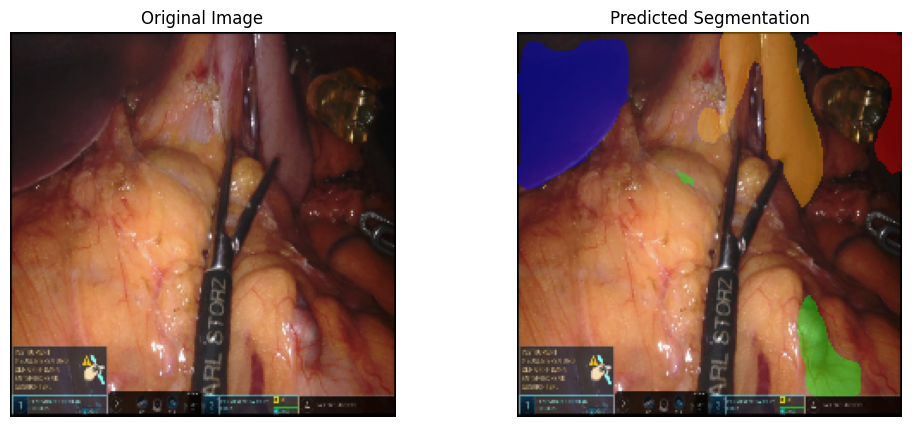

🧠 Detected Anatomies:
 - abdominal_wall (Red)
 - colon (Green)
 - liver (Blue)
 - stomach (Orange)


In [ ]:
# ---- Run ----
test_single_image(
    image_path="/content/DATASET/TEST/IMAGE/img054.png",
    model=model,
    device=device
)